In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('/home/nihal_farooq_m/Bro_Files/Week 14/Datasets 14/weight-height.csv')
df

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


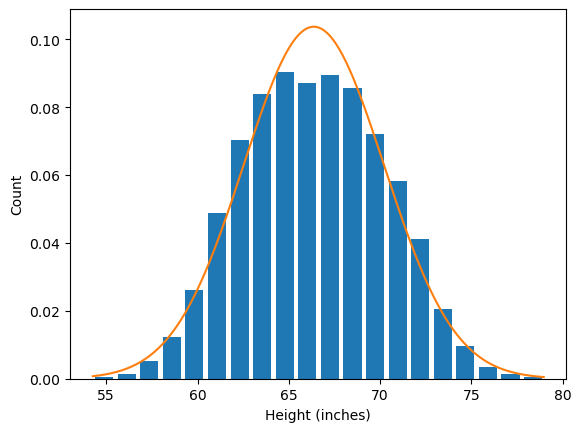

In [3]:
from scipy.stats import norm
import numpy as np

plt.hist(df.Height, bins = 20, rwidth = 0.8, density = True)
plt.xlabel('Height (inches)')
plt.ylabel('Count')

rng = np.arange(df.Height.min(), df.Height.max(), 0.1)
plt.plot(rng, norm.pdf(rng, df.Height.mean(), df.Height.std()))

plt.show()

<Axes: xlabel='Height', ylabel='Count'>

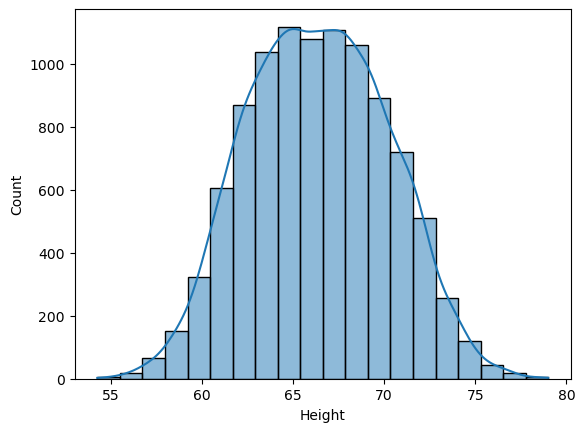

In [4]:
import seaborn as sns
sns.histplot(df.Height, bins = 20, kde = True)

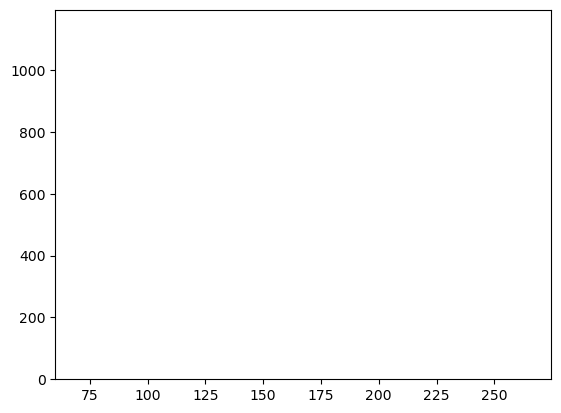

In [5]:
plt.hist(df.Weight, bins = 20, rwidth = 0.);

In [6]:
df.Height.describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

In [7]:
ht_mean, ht_std = df.Height.mean(), df.Height.std()
print(ht_mean, ht_std)

66.36755975482124 3.8475281207732293


In [8]:
up_lmt = ht_mean + 3 * ht_std
lo_lmt = ht_mean - 3 * ht_std
print(up_lmt, lo_lmt)

77.91014411714093 54.82497539250156


In [9]:
df[(df.Height > up_lmt) | (df.Height < lo_lmt)]

,Gender,Height,Weight
994,Male,78.095867,255.690835
1317,Male,78.462053,227.342565
2014,Male,78.998742,269.989699
3285,Male,78.528210,253.889004
3757,Male,78.621374,245.733783
6624,Female,54.616858,71.393749
9285,Female,54.263133,64.700127


In [10]:
df_new = df[(df.Height < up_lmt) & (df.Height > lo_lmt)]
df_new

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


In [11]:
df['ht_zscore'] = (df.Height - ht_mean) / ht_std
df

,Gender,Height,Weight,ht_zscore
0,Male,73.847017,241.893563,1.943964
1,Male,68.781904,162.310473,0.627505
2,Male,74.110105,212.740856,2.012343
3,Male,71.730978,220.042470,1.393991
4,Male,69.881796,206.349801,0.913375
...,...,...,...,...
9995,Female,66.172652,136.777454,-0.050658
9996,Female,67.067155,170.867906,0.181830
9997,Female,63.867992,128.475319,-0.649655
9998,Female,69.034243,163.852461,0.693090


In [12]:
df[df['ht_zscore'] > 3]

,Gender,Height,Weight,ht_zscore
994,Male,78.095867,255.690835,3.048271
1317,Male,78.462053,227.342565,3.143445
2014,Male,78.998742,269.989699,3.282934
3285,Male,78.528210,253.889004,3.160640
3757,Male,78.621374,245.733783,3.184854


In [13]:
df[df['ht_zscore'] < -3]

,Gender,Height,Weight,ht_zscore
6624,Female,54.616858,71.393749,-3.054091
9285,Female,54.263133,64.700127,-3.146027


In [14]:
df[(df['ht_zscore'] > 3) | (df['ht_zscore'] < -3)]

,Gender,Height,Weight,ht_zscore
994,Male,78.095867,255.690835,3.048271
1317,Male,78.462053,227.342565,3.143445
2014,Male,78.998742,269.989699,3.282934
3285,Male,78.528210,253.889004,3.160640
3757,Male,78.621374,245.733783,3.184854
6624,Female,54.616858,71.393749,-3.054091
9285,Female,54.263133,64.700127,-3.146027


In [15]:
df_zscore_new = df[(df['ht_zscore'] > -3) & (df['ht_zscore'] < 3)]
df_zscore_new

,Gender,Height,Weight,ht_zscore
0,Male,73.847017,241.893563,1.943964
1,Male,68.781904,162.310473,0.627505
2,Male,74.110105,212.740856,2.012343
3,Male,71.730978,220.042470,1.393991
4,Male,69.881796,206.349801,0.913375
...,...,...,...,...
9995,Female,66.172652,136.777454,-0.050658
9996,Female,67.067155,170.867906,0.181830
9997,Female,63.867992,128.475319,-0.649655
9998,Female,69.034243,163.852461,0.693090
